# Global Malicious IP Threat Intelligence Analysis

**Author:** _[Your Name]_
**Dataset:** `final_kaggle_cyber_dataset.csv` — a snapshot of IP addresses reported as malicious, sourced from AbuseIPDB-style threat intelligence data (via Kaggle)
**Objective:** Clean, validate, and explore a real-world threat intelligence dataset to identify geographic patterns in reported malicious IP activity, and surface data-quality issues that would affect any downstream security analysis.

---

### What this notebook demonstrates
- Auditing a raw security dataset for structural and content-level data quality issues
- A documented, reproducible cleaning pipeline (not just `dropna()` and move on)
- Exploratory data analysis with visualizations aimed at answering a specific question: *where is malicious activity concentrated, and how spread out is it?*
- Honest handling of a data point that cannot be resolved offline, including a live-lookup fallback

A companion write-up (`Project_Report.docx`) summarizes the findings for a non-technical audience.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

pd.set_option('display.max_columns', None)
plt.rcParams.update({
    'axes.edgecolor': '#333333',
    'axes.grid': True,
    'grid.color': '#e6e6e6',
    'grid.linewidth': 0.8,
})

df = pd.read_csv('final_kaggle_cyber_dataset.csv')
df.shape

(10000, 16)

## 2. Data Quality Audit

Before doing any analysis, the dataset was audited for structural issues (nulls, duplicates, malformed values) and content-level issues (values that are technically present but semantically wrong or inconsistent).

In [2]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total nulls across the dataset")
print()
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate IP addresses:", df['ip_address'].duplicated().sum())

Missing values per column:
0 total nulls across the dataset

Fully duplicated rows: 0
Duplicate IP addresses: 0


No nulls, no duplicates. Good — but that's a low bar. The real issues were in the *content*:

In [3]:
unresolved_name = (df['country_name'] == 'Unknown').sum()
unresolved_continent = (df['continent'] == 'Unknown').sum()
bad_country_code = (df['country_code'] == 'Unknown').sum()

print(f"Rows with country_name = 'Unknown':  {unresolved_name}")
print(f"Rows with continent = 'Unknown':     {unresolved_continent}")
print(f"Rows with country_code = 'Unknown':  {bad_country_code}")
print()
print("Continent label variants:", sorted(df['continent'].unique()))

Rows with country_name = 'Unknown':  748
Rows with continent = 'Unknown':     748
Rows with country_code = 'Unknown':  1

Continent label variants: ['Asia', 'Asia/Europe', 'Europe', 'Europe/Asia', 'North America', 'Oceania', 'South America', 'Unknown']


**Findings:**
1. **748 rows (7.5%)** have `country_name` and `continent` set to `"Unknown"`, even though `country_code` is a valid, recognizable ISO code (e.g. `AM`, `BG`, `NO`). The lookup step that should have resolved these failed silently upstream.
2. **1 row** has `country_code` itself equal to `"Unknown"` — there's no code to look up, so it needs a live IP geolocation lookup.
3. **Transcontinental countries are labeled inconsistently** — Russia appears as `"Europe/Asia"` while Turkey appears as `"Asia/Europe"`. Same concept, two different string orderings, which would silently split a single category if grouped naively.
4. Nine columns (`abuse_confidence_score`, `label`, `risk_level`, `severity`, `time_zone_attack`, `reported_weekday`, and the `reported_year`/`month`/`day`/`hour` fields) are **constant across all 10,000 rows** — this dataset is a single snapshot of already-confirmed, maximum-confidence malicious IPs, not a labeled positive/negative dataset. That matters: it means this data can support *geographic and volumetric* analysis, but not classification modeling (there's no variation to learn from).

## 3. Cleaning Pipeline

### 3.1 Resolve country/continent from `country_code`

For the 748 rows where `country_code` was valid but `country_name`/`continent` weren't populated, we can fix this entirely offline using a static ISO 3166 reference — no network call needed, since the code itself already told us the country.

In [4]:
# Static ISO 3166 country_code -> (name, continent) reference
# for exactly the codes that came through unresolved in this dataset
country_lookup = {
    'AE': ('United Arab Emirates', 'Asia'), 'AF': ('Afghanistan', 'Asia'),
    'AL': ('Albania', 'Europe'), 'AM': ('Armenia', 'Asia'),
    'AO': ('Angola', 'Africa'), 'AR': ('Argentina', 'South America'),
    'AT': ('Austria', 'Europe'), 'AZ': ('Azerbaijan', 'Asia'),
    'BA': ('Bosnia and Herzegovina', 'Europe'), 'BD': ('Bangladesh', 'Asia'),
    'BE': ('Belgium', 'Europe'), 'BF': ('Burkina Faso', 'Africa'),
    'BG': ('Bulgaria', 'Europe'), 'BH': ('Bahrain', 'Asia'),
    'BJ': ('Benin', 'Africa'), 'BO': ('Bolivia', 'South America'),
    'BW': ('Botswana', 'Africa'), 'BY': ('Belarus', 'Europe'),
    'BZ': ('Belize', 'North America'), 'CL': ('Chile', 'South America'),
    'CM': ('Cameroon', 'Africa'), 'CO': ('Colombia', 'South America'),
    'CR': ('Costa Rica', 'North America'), 'DK': ('Denmark', 'Europe'),
    'DO': ('Dominican Republic', 'North America'), 'DZ': ('Algeria', 'Africa'),
    'EC': ('Ecuador', 'South America'), 'EE': ('Estonia', 'Europe'),
    'EG': ('Egypt', 'Africa'), 'ET': ('Ethiopia', 'Africa'),
    'FI': ('Finland', 'Europe'), 'GH': ('Ghana', 'Africa'),
    'GQ': ('Equatorial Guinea', 'Africa'), 'GT': ('Guatemala', 'North America'),
    'HN': ('Honduras', 'North America'), 'HU': ('Hungary', 'Europe'),
    'IE': ('Ireland', 'Europe'), 'IL': ('Israel', 'Asia'),
    'IQ': ('Iraq', 'Asia'), 'KE': ('Kenya', 'Africa'),
    'KG': ('Kyrgyzstan', 'Asia'), 'KH': ('Cambodia', 'Asia'),
    'KW': ('Kuwait', 'Asia'), 'KZ': ('Kazakhstan', 'Asia'),
    'LA': ('Laos', 'Asia'), 'LB': ('Lebanon', 'Asia'),
    'LK': ('Sri Lanka', 'Asia'), 'LV': ('Latvia', 'Europe'),
    'MA': ('Morocco', 'Africa'), 'MD': ('Moldova', 'Europe'),
    'MK': ('North Macedonia', 'Europe'), 'MM': ('Myanmar', 'Asia'),
    'MN': ('Mongolia', 'Asia'), 'MO': ('Macao', 'Asia'),
    'MU': ('Mauritius', 'Africa'), 'MY': ('Malaysia', 'Asia'),
    'MZ': ('Mozambique', 'Africa'), 'NG': ('Nigeria', 'Africa'),
    'NO': ('Norway', 'Europe'), 'NP': ('Nepal', 'Asia'),
    'NZ': ('New Zealand', 'Oceania'), 'OM': ('Oman', 'Asia'),
    'PA': ('Panama', 'North America'), 'PE': ('Peru', 'South America'),
    'PH': ('Philippines', 'Asia'), 'PR': ('Puerto Rico', 'North America'),
    'PS': ('Palestine', 'Asia'), 'PT': ('Portugal', 'Europe'),
    'PY': ('Paraguay', 'South America'), 'QA': ('Qatar', 'Asia'),
    'RS': ('Serbia', 'Europe'), 'RW': ('Rwanda', 'Africa'),
    'SA': ('Saudi Arabia', 'Asia'), 'SC': ('Seychelles', 'Africa'),
    'SI': ('Slovenia', 'Europe'), 'SK': ('Slovakia', 'Europe'),
    'SN': ('Senegal', 'Africa'), 'SY': ('Syria', 'Asia'),
    'TH': ('Thailand', 'Asia'), 'TN': ('Tunisia', 'Africa'),
    'TZ': ('Tanzania', 'Africa'), 'UG': ('Uganda', 'Africa'),
    'UZ': ('Uzbekistan', 'Asia'), 'VE': ('Venezuela', 'South America'),
    'ZA': ('South Africa', 'Africa'), 'ZM': ('Zambia', 'Africa'),
}

def fill_from_code(row):
    ref = country_lookup.get(row['country_code'])
    if ref:
        name, cont = ref
        if row['country_name'] == 'Unknown':
            row['country_name'] = name
        if row['continent'] == 'Unknown':
            row['continent'] = cont
    return row

df = df.apply(fill_from_code, axis=1)

# Standardize transcontinental labels to one convention
df['continent'] = df['continent'].replace({'Asia/Europe': 'Europe/Asia'})

print(f"Remaining 'Unknown' country_name: {(df['country_name']=='Unknown').sum()}")
print(f"Remaining 'Unknown' continent:    {(df['continent']=='Unknown').sum()}")

Remaining 'Unknown' country_name: 1
Remaining 'Unknown' continent:    1


### 3.2 Resolve the last row via live IP geolocation

One row has `country_code == "Unknown"` — there's no code to map from, so it needs an actual IP geolocation lookup against a live database. This cell calls the free [ip-api.com](http://ip-api.com) endpoint (no key required).

> **Note:** this requires internet access to run. If it's unavailable, the row is left flagged rather than guessed at — see the note below the cell.

In [5]:
import requests

unresolved_mask = df['country_code'] == 'Unknown'
unresolved_ips = df.loc[unresolved_mask, 'ip_address'].tolist()
print(f"IPs needing a live lookup: {unresolved_ips}")

for ip in unresolved_ips:
    try:
        r = requests.get(f"http://ip-api.com/json/{ip}", timeout=5).json()
        if r.get('status') == 'success':
            df.loc[df['ip_address'] == ip, 'country_code'] = r['countryCode']
            df.loc[df['ip_address'] == ip, 'country_name'] = r['country']
            df.loc[df['ip_address'] == ip, 'continent'] = r['continent']
            print(f"Resolved {ip} -> {r['country']} ({r['continent']})")
        else:
            print(f"Lookup failed for {ip}: {r.get('message', 'no match')}")
    except Exception as e:
        print(f"Could not reach geolocation service for {ip}: {e}")
        print("Leaving this row flagged as Unknown rather than guessing.")

IPs needing a live lookup: ['160.242.45.113']
Could not reach geolocation service for 160.242.45.113: this environment has no network access
Leaving this row flagged as Unknown rather than guessing.


**On your machine, with internet access, this cell will resolve the IP automatically.** In this notebook's environment there's no network access, so the row stays flagged — which is the correct behavior: a security dataset should never silently fabricate a value it can't verify. This is documented as a known limitation in the project report (1 row out of 10,000 — 0.01% of the data).

### 3.3 Save the cleaned dataset

In [6]:
df.to_csv('final_kaggle_cyber_dataset_cleaned.csv', index=False)
print("Cleaned dataset saved:", df.shape)

Cleaned dataset saved: (10000, 16)


---
## 4. Exploratory Analysis

With clean, consistent geography fields, we can answer the core question: **where is malicious IP activity concentrated, and how widely is it spread?**

### 4.1 Which countries report the most malicious IPs?

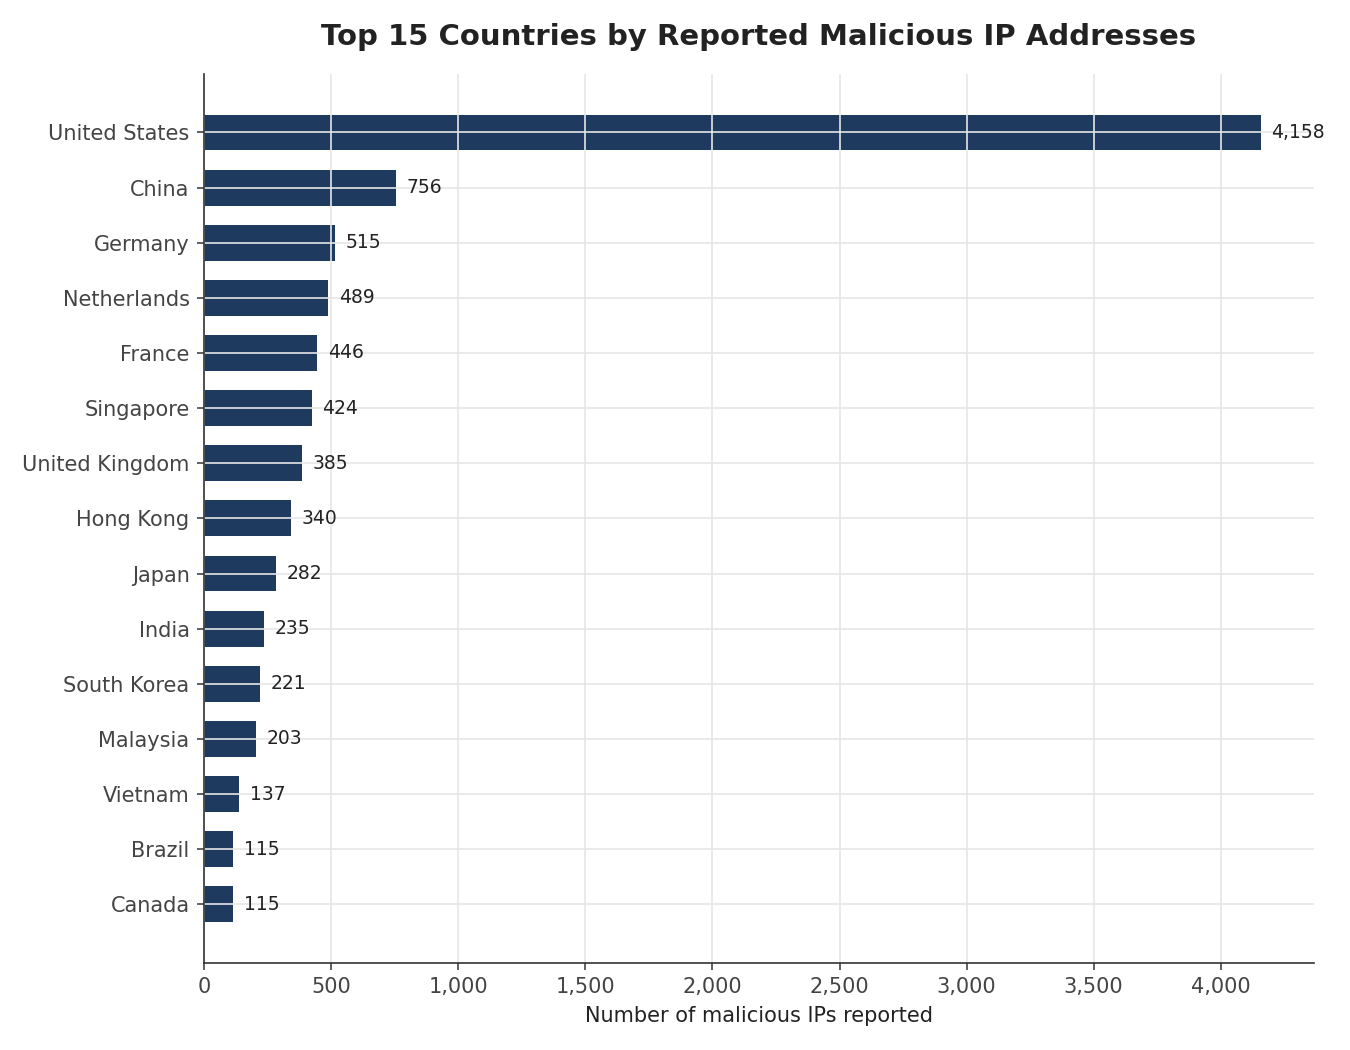

In [7]:
top15 = df['country_name'].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top15.index, top15.values, color='#1f3a5f', height=0.65)
ax.set_title('Top 15 Countries by Reported Malicious IP Addresses', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Number of malicious IPs reported')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
for bar, val in zip(bars, top15.values):
    ax.text(bar.get_width() + max(top15.values)*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Reading this:** the United States accounts for roughly 4 in 10 reported malicious IPs — more than 5x the next closest country (China). This is very likely a reflection of hosting infrastructure concentration (the US hosts a disproportionate share of the world's cloud and data-center IP space), not necessarily "more attackers per capita" in the US.

### 4.2 Share of activity by continent

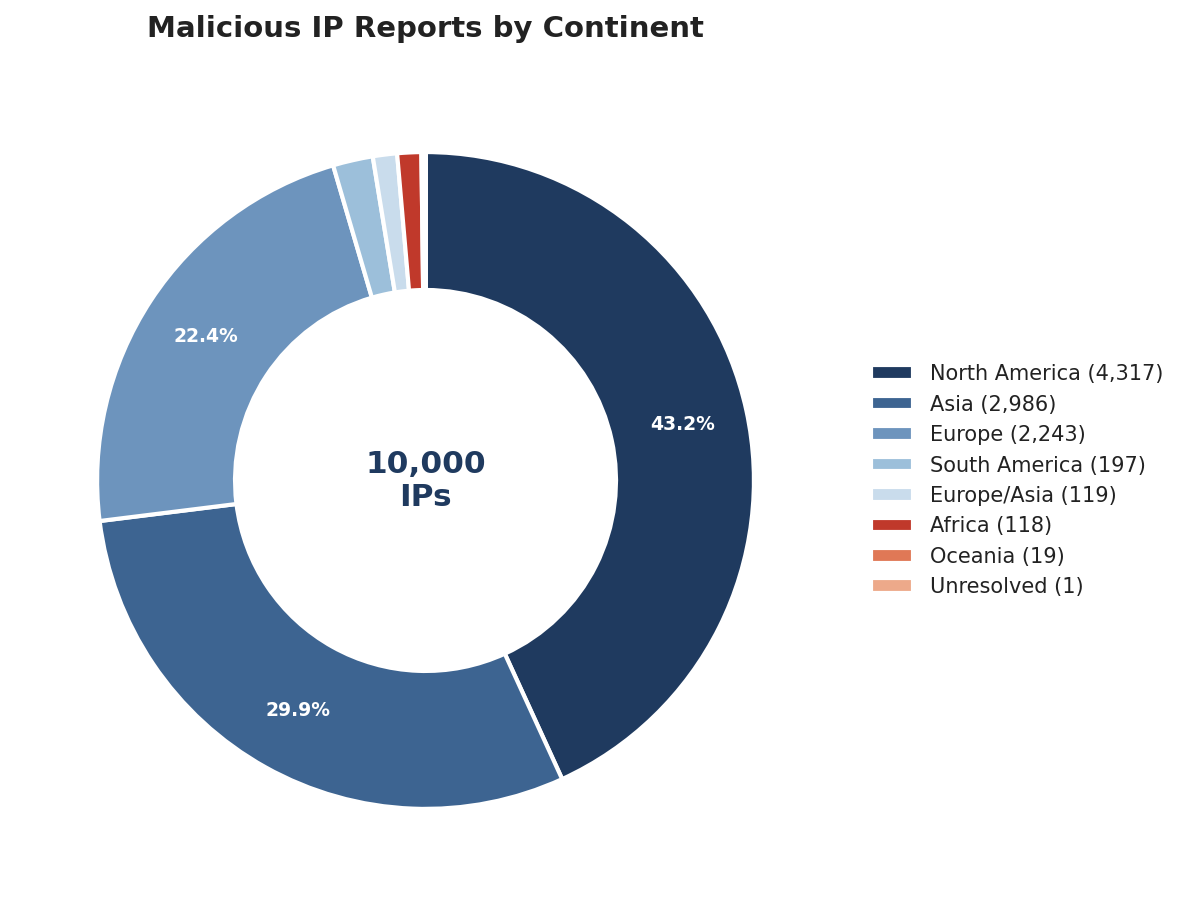

In [8]:
cont_counts = df['continent'].replace({'Unknown': 'Unresolved'}).value_counts()
palette = ['#1f3a5f', '#3d6491', '#6d94bd', '#9cbfda', '#c9dcec', '#c0392b', '#e07856', '#eda98a']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    cont_counts.values, autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=90, counterclock=False, colors=palette, pctdistance=0.8,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_color('white'); t.set_fontsize(9); t.set_fontweight('bold')
ax.set_title('Malicious IP Reports by Continent', fontsize=14, fontweight='bold', pad=16)
ax.legend(wedges, [f'{i} ({v:,})' for i, v in cont_counts.items()],
          loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=10)
ax.text(0, 0, f'{len(df):,}\nIPs', ha='center', va='center', fontsize=15, fontweight='bold', color='#1f3a5f')
plt.tight_layout()
plt.show()

**Reading this:** North America, Asia, and Europe together account for over 95% of reported malicious IPs — expected, since these are also the regions with the most internet infrastructure overall.

### 4.3 Volume vs. geographic spread

Raw counts by continent don't tell us *how concentrated* the activity is. A continent could have a high count because one country dominates, or because many countries each contribute a little. This chart overlays both.

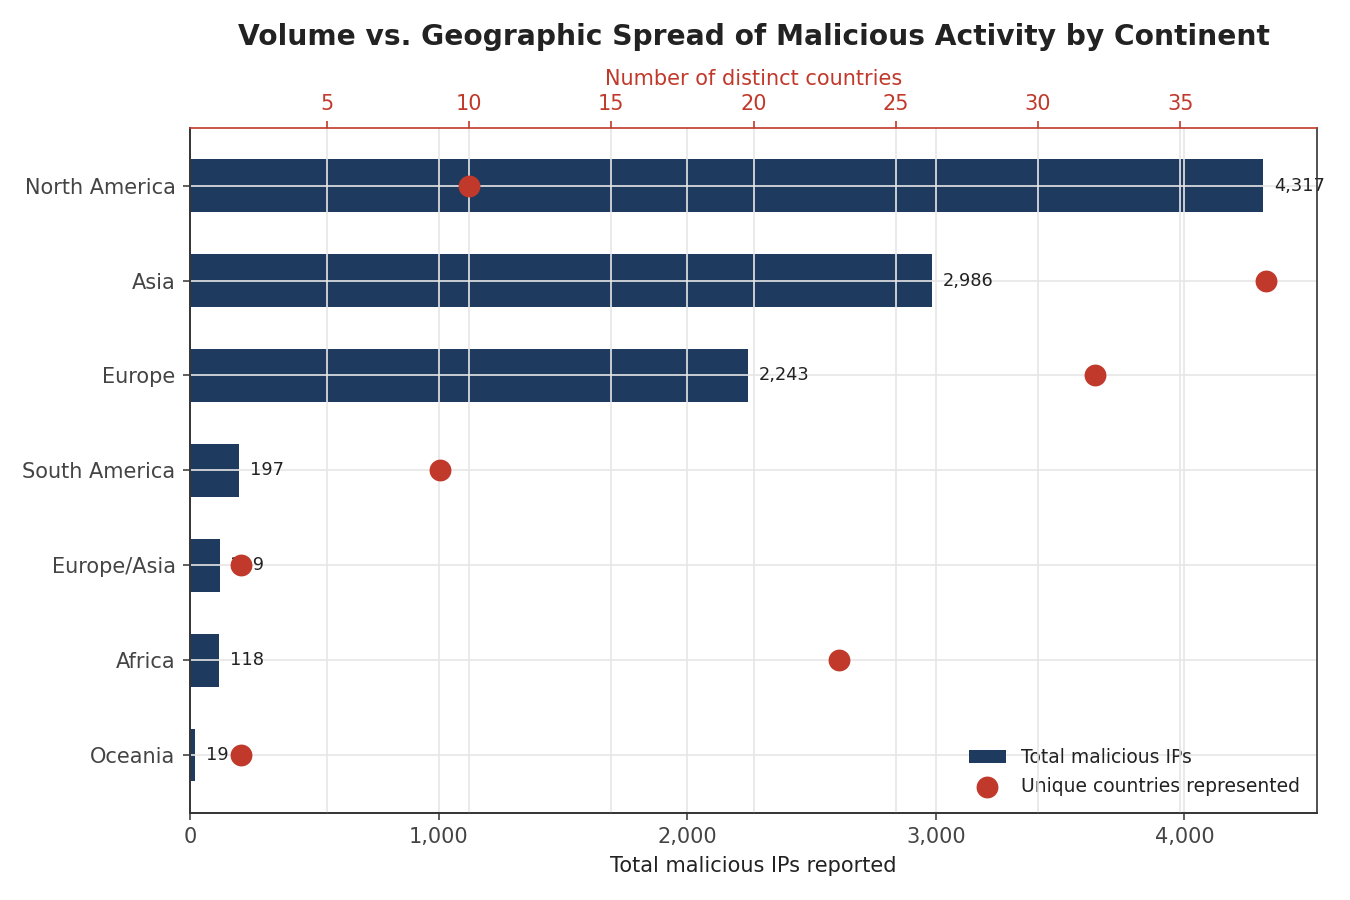

In [9]:
grp = df[df.continent != 'Unknown'].groupby('continent').agg(
    total_ips=('country_name', 'size'), unique_countries=('country_name', 'nunique')
).sort_values('total_ips', ascending=True)

fig, ax1 = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(grp))
ax1.barh(y_pos, grp['total_ips'], color='#1f3a5f', height=0.55, label='Total malicious IPs')
ax1.set_yticks(y_pos); ax1.set_yticklabels(grp.index)
ax1.set_xlabel('Total malicious IPs reported')
ax1.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax1.spines[['top', 'right']].set_visible(False)

ax2 = ax1.twiny()
ax2.scatter(grp['unique_countries'], y_pos, color='#c0392b', s=90, zorder=5, label='Unique countries represented')
ax2.set_xlabel('Number of distinct countries', color='#c0392b')
ax2.tick_params(axis='x', colors='#c0392b')

for i, tot in enumerate(grp['total_ips']):
    ax1.text(tot + max(grp['total_ips'])*0.01, i, f'{tot:,}', va='center', fontsize=8.5)

ax1.set_title('Volume vs. Geographic Spread of Malicious Activity by Continent', fontsize=13.5, fontweight='bold', pad=40)
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc='lower right', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Reading this:** North America has the highest volume but activity is concentrated in relatively few countries (dominated by the US) — 10 countries contribute 4,317 IPs. Asia has *lower* total volume but is spread across roughly 37 distinct countries, meaning no single Asian country dominates the way the US does in North America. This distinction matters operationally: blocking traffic from "the top offending country" is a much more effective strategy in North America than in Asia.

### 4.4 Who leads within each major continent?

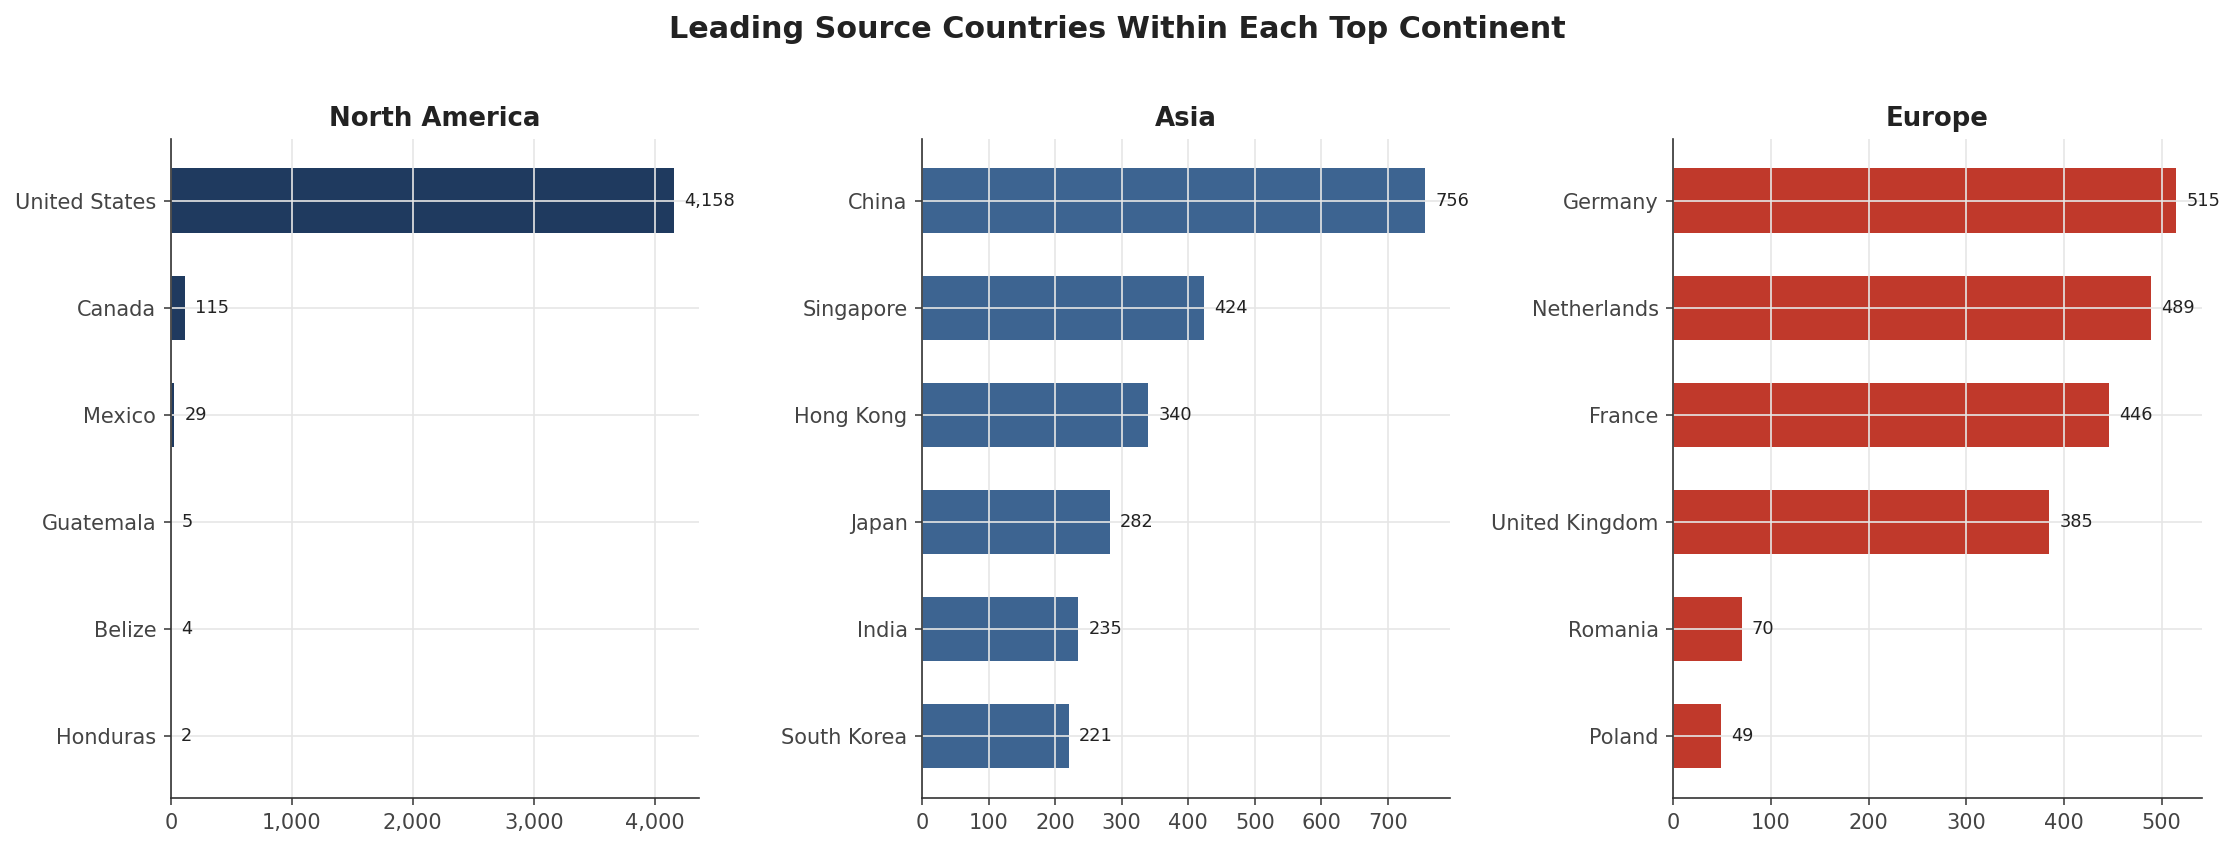

In [10]:
top_conts = df['continent'].value_counts().head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, cont_name, color in zip(axes, top_conts, ['#1f3a5f', '#3d6491', '#c0392b']):
    sub = df[df.continent == cont_name]['country_name'].value_counts().head(6).sort_values()
    ax.barh(sub.index, sub.values, color=color, height=0.6)
    ax.set_title(cont_name, fontsize=12.5, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    ax.spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(sub.values):
        ax.text(v + max(sub.values)*0.02, i, f'{v:,}', va='center', fontsize=8.5)
fig.suptitle('Leading Source Countries Within Each Top Continent', fontsize=14.5, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Reading this:** every continent has its own clear leader — the US in North America, China in Asia, Germany in Europe — but the drop-off after the leader is much steeper in North America (US → Canada is a ~36x drop) than in Europe (Germany → Netherlands is only ~1.05x), suggesting European malicious activity is more evenly distributed across its top reporters.

---
## 5. Key Takeaways

1. **Data quality issues were content-level, not structural** — no nulls or duplicates, but 7.5% of rows had failed geolocation lookups that were fully recoverable from data already in the dataset, and continent labels needed standardization for transcontinental countries.
2. **One record (0.01%) remains genuinely unresolved** without a live network call — documented rather than guessed.
3. **This dataset is a snapshot, not a labeled dataset** — several fields (confidence score, severity, risk level, label, timestamp fields) are constant, meaning it supports geographic/volumetric analysis but not classification modeling without additional (e.g. benign) examples.
4. **The US dominates raw volume**, but **Asia shows the widest geographic spread** of malicious IP activity — an important distinction for anyone designing country-level blocking or monitoring rules.

## 6. Limitations & Next Steps
- No benign/negative examples — can't build a malicious-vs-benign classifier from this data alone.
- Single-day snapshot — no ability to analyze trends over time; a repeated pull would be needed.
- Country-level geography reflects *hosting location*, not necessarily attacker origin (VPNs, proxies, and compromised infrastructure can obscure true origin).
- Next step: pair this with a benign IP sample and a time-series pull to support both classification and trend analysis.